# DAPSTOM 6.4 Visual EDA and Representative Networks

This is an executable visual notebook. Each figure has a code cell with editable titles, colours, limits and layout parameters. Running one figure cell regenerates only its named SVG; running all cells reproduces the complete visual EDA from the derived CSV tables.

## Reproducibility and customisation workflow

The source Access database is not queried or modified by the plotting cells. Data extraction remains in `tools/DapstomEdaExtractor.java`; network derivation remains in `tools/derive_network_metrics.py`; reusable SVG drawing functions remain in `tools/build_visual_notebook.py`.

To refresh every derived table before running this notebook:

```bash
bash data/processed/dapstom_eda/tools/run_extractor.sh
python3 data/processed/dapstom_eda/tools/derive_network_metrics.py
```

After that, use **Kernel → Restart & Run All**, or edit and run a single figure cell.

In [1]:
from pathlib import Path
import sys

try:
    from IPython.display import SVG, display
except ImportError:
    SVG = None
    display = None


def locate_eda_directory():
    current = Path.cwd().resolve()
    for root in [current, *current.parents]:
        if root.name == "dapstom_eda" and (root / "tables").exists():
            return root
        candidate = root / "data" / "processed" / "dapstom_eda"
        if (candidate / "tables").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/processed/dapstom_eda")


EDA_DIR = locate_eda_directory()
TABLE_DIR = EDA_DIR / "tables"
FIG_DIR = EDA_DIR / "figures"
TOOLS_DIR = EDA_DIR / "tools"

if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

import build_visual_notebook as viz
from derive_network_metrics import derive

viz.TABLE_DIR = TABLE_DIR
viz.FIG_DIR = FIG_DIR


def show_svg(figure_name):
    figure_path = FIG_DIR / figure_name
    if SVG is None:
        return figure_path
    display(SVG(filename=str(figure_path)))


EDA_DIR


PosixPath('/Users/acw792/Developer/qmul-phd-framework/data/processed/dapstom_eda')

### Global visual style

Change this cell to update the shared palette, trophic-role colours, grid, text and background. Rerun the desired figure cells afterwards.

In [2]:
STYLE = {
    "palette": ["#36648B", "#4C8C5A", "#C46A2D", "#7E5AA2", "#A23E48", "#548C8C"],
    "predator": "#36648B",
    "prey": "#4C8C5A",
    "non_trophic": "#C46A2D",
    "both_roles": "#7E5AA2",
    "grid": "#D8DEE4",
    "text": "#1F2933",
    "muted_text": "#52616B",
    "background": "#FFFFFF",
    "font_family": '-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif',
    "base_font_size": 13,
    "title_font_size": 22,
    "subtitle_font_size": 13,
    "small_font_size": 11,
}

viz.PALETTE = STYLE["palette"]
viz.PRED_COLOR = STYLE["predator"]
viz.PREY_COLOR = STYLE["prey"]
viz.NON_TROPHIC_COLOR = STYLE["non_trophic"]
viz.BOTH_ROLE_COLOR = STYLE["both_roles"]
viz.GRID_COLOR = STYLE["grid"]
viz.TEXT_COLOR = STYLE["text"]
viz.MUTED_TEXT = STYLE["muted_text"]
viz.BG = STYLE["background"]
viz.FONT_FAMILY = STYLE["font_family"]
viz.BASE_FONT_SIZE = STYLE["base_font_size"]
viz.TITLE_FONT_SIZE = STYLE["title_font_size"]
viz.SUBTITLE_FONT_SIZE = STYLE["subtitle_font_size"]
viz.SMALL_FONT_SIZE = STYLE["small_font_size"]


## 1. Database Scale

Source: `table_row_counts.csv`. Adjust `LIMIT`, colour, width, label space or row height.

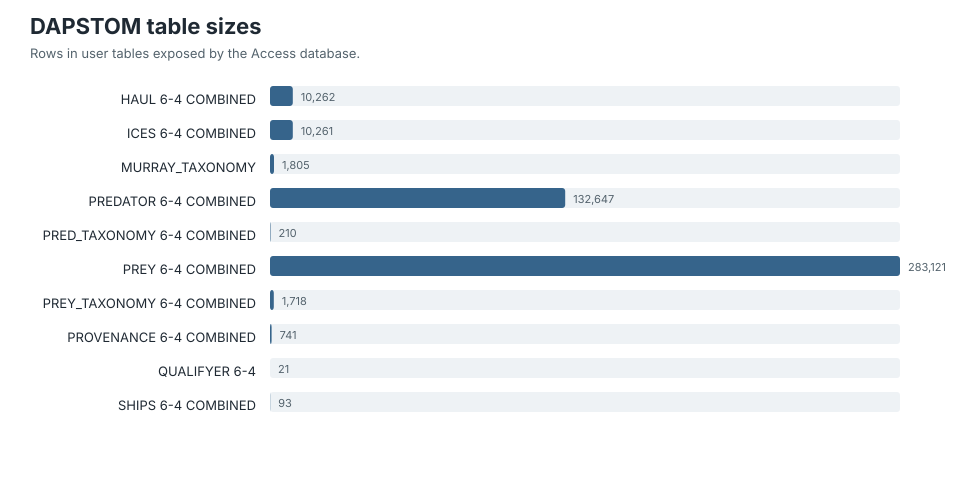

In [3]:
FIGURE_NAME = "table_row_counts.svg"
LIMIT = 10

rows = viz.read_rows("table_row_counts")
viz.horizontal_bar_chart(
    name=FIGURE_NAME,
    title="DAPSTOM table sizes",
    subtitle="Rows in user tables exposed by the Access database.",
    rows=rows,
    value_key="row_count",
    label_key="table_name",
    limit=LIMIT,
    color=STYLE["predator"],
    width=980,
    row_height=34,
    left=270,
    right=80,
)
show_svg(FIGURE_NAME)


## 2. Temporal Coverage

Source: `haul_temporal_by_decade.csv`. Bar colour, canvas dimensions and spacing are editable.

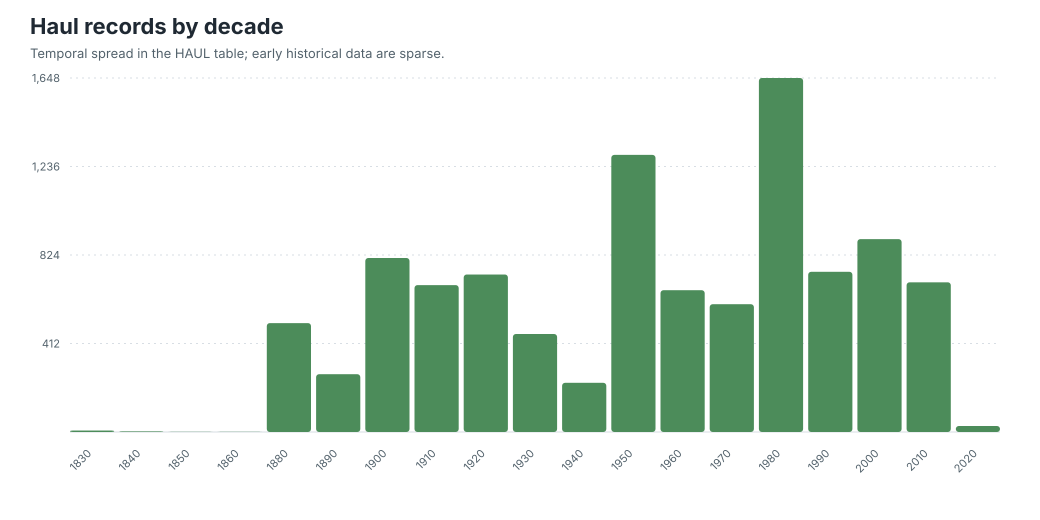

In [4]:
FIGURE_NAME = "hauls_by_decade.svg"

rows = viz.read_rows("haul_temporal_by_decade")
viz.vertical_bar_chart(
    name=FIGURE_NAME,
    title="Haul records by decade",
    subtitle="Temporal spread in the HAUL table; early historical data are sparse.",
    rows=rows,
    value_key="haul_rows",
    label_key="decade",
    color=STYLE["prey"],
    width=1040,
    height=520,
    bar_gap=5,
)
show_svg(FIGURE_NAME)


Temporal coverage is long but highly uneven; apparent temporal network change must be compared with effort.

## 3. Spatial Coverage — hauls by sea

Source: `haul_spatial_by_sea.csv`. `LIMIT` controls the number of seas displayed.

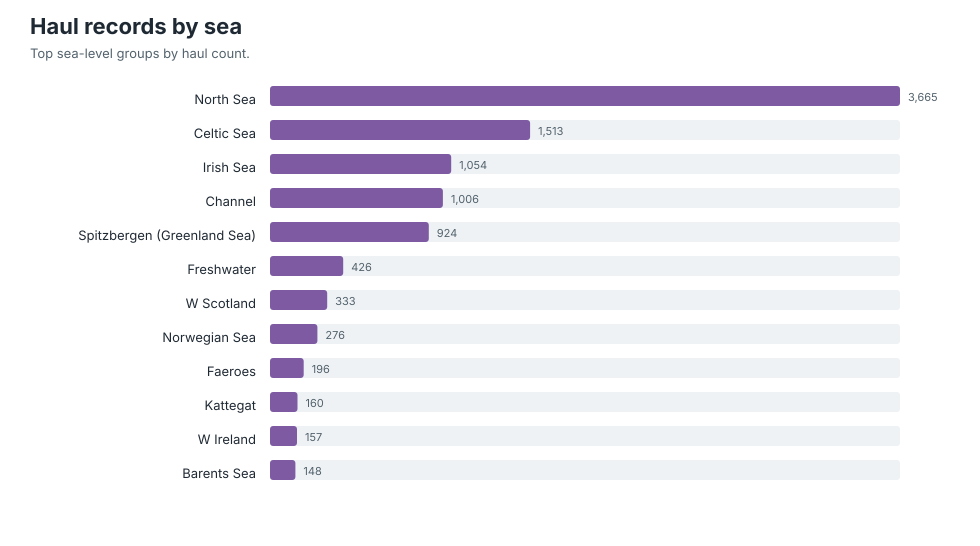

In [5]:
FIGURE_NAME = "hauls_by_sea.svg"
LIMIT = 12

rows = viz.read_rows("haul_spatial_by_sea")
viz.horizontal_bar_chart(
    name=FIGURE_NAME,
    title="Haul records by sea",
    subtitle="Top sea-level groups by haul count.",
    rows=rows,
    value_key="haul_rows",
    label_key="sea",
    limit=LIMIT,
    color=STYLE["both_roles"],
    width=980,
    row_height=34,
    left=270,
    right=80,
)
show_svg(FIGURE_NAME)


### Spatial resolution

Source: `haul_spatial_resolution.csv`. Edit the colour sequence, canvas and bar width.

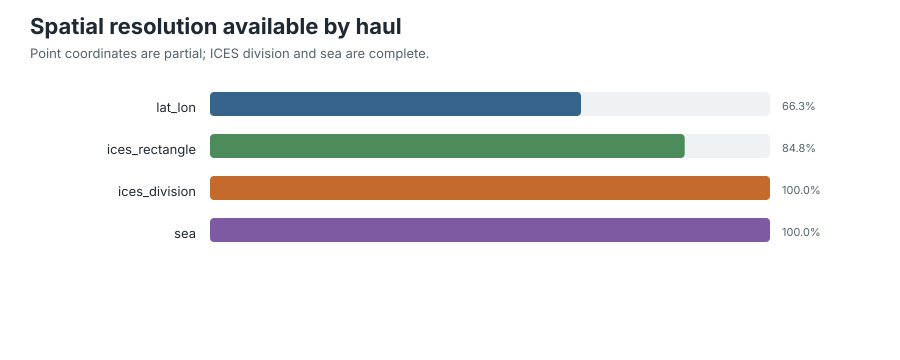

In [6]:
FIGURE_NAME = "spatial_resolution_coverage.svg"

viz.spatial_coverage_chart(
    name=FIGURE_NAME,
    title="Spatial resolution available by haul",
    subtitle="Point coordinates are partial; ICES division and sea are complete.",
    width=900,
    height=360,
    left=210,
    top=92,
    plot_width=560,
    row_height=42,
    colors=STYLE["palette"],
)
show_svg(FIGURE_NAME)


## 4. Sampling Unit: Pooled vs Individual

Source: `predator_pooling_summary.csv`. Category colours, labels and geometry are visible below.

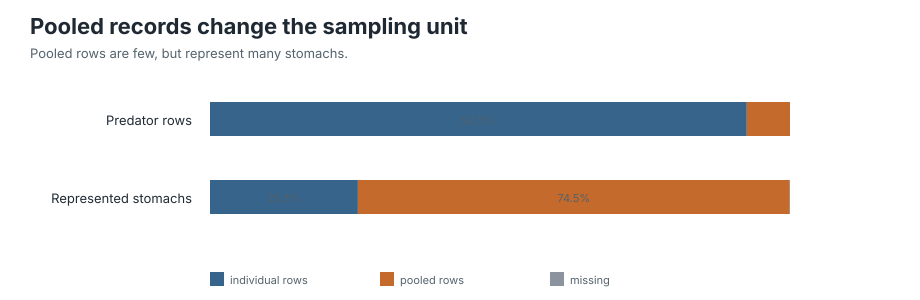

In [7]:
FIGURE_NAME = "pooled_rows_vs_stomachs.svg"
POOL_COLOURS = {
    "n": STYLE["predator"],
    "y": STYLE["non_trophic"],
    "": "#8B949E",
}
POOL_LABELS = {
    "n": "individual rows",
    "y": "pooled rows",
    "": "missing",
}

viz.pooled_comparison_chart(
    name=FIGURE_NAME,
    title="Pooled records change the sampling unit",
    subtitle="Pooled rows are few, but represent many stomachs.",
    width=920,
    height=300,
    bar_width=580,
    bar_height=34,
    colors=POOL_COLOURS,
    labels=POOL_LABELS,
)
show_svg(FIGURE_NAME)


Pooled records are not exchangeable with individual-stomach rows. Report hauls and represented stomachs rather than treating row count alone as effort.

## 5. Missingness

Source: `critical_field_missingness.csv`. `LIMIT` controls the number of fields shown.

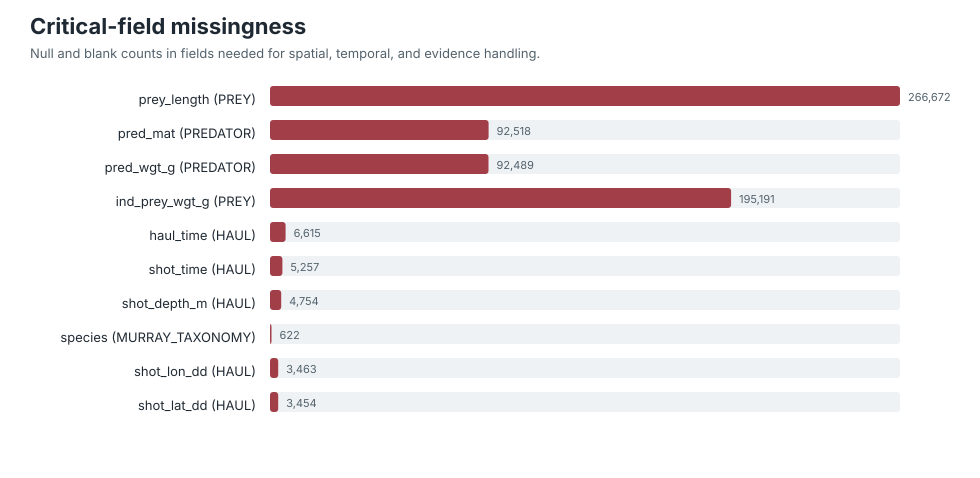

In [8]:
FIGURE_NAME = "critical_missingness.svg"
LIMIT = 10

viz.missingness_chart(
    name=FIGURE_NAME,
    title="Critical-field missingness",
    subtitle="Null and blank counts in fields needed for spatial, temporal, and evidence handling.",
    limit=LIMIT,
    color="#A23E48",
)
show_svg(FIGURE_NAME)


## 6. Continuous-variable Distributions and Outlier Context

Sources: `numeric_variable_histograms.csv` and `numeric_variable_summary.csv`. Edit panel dimensions, titles and palette.

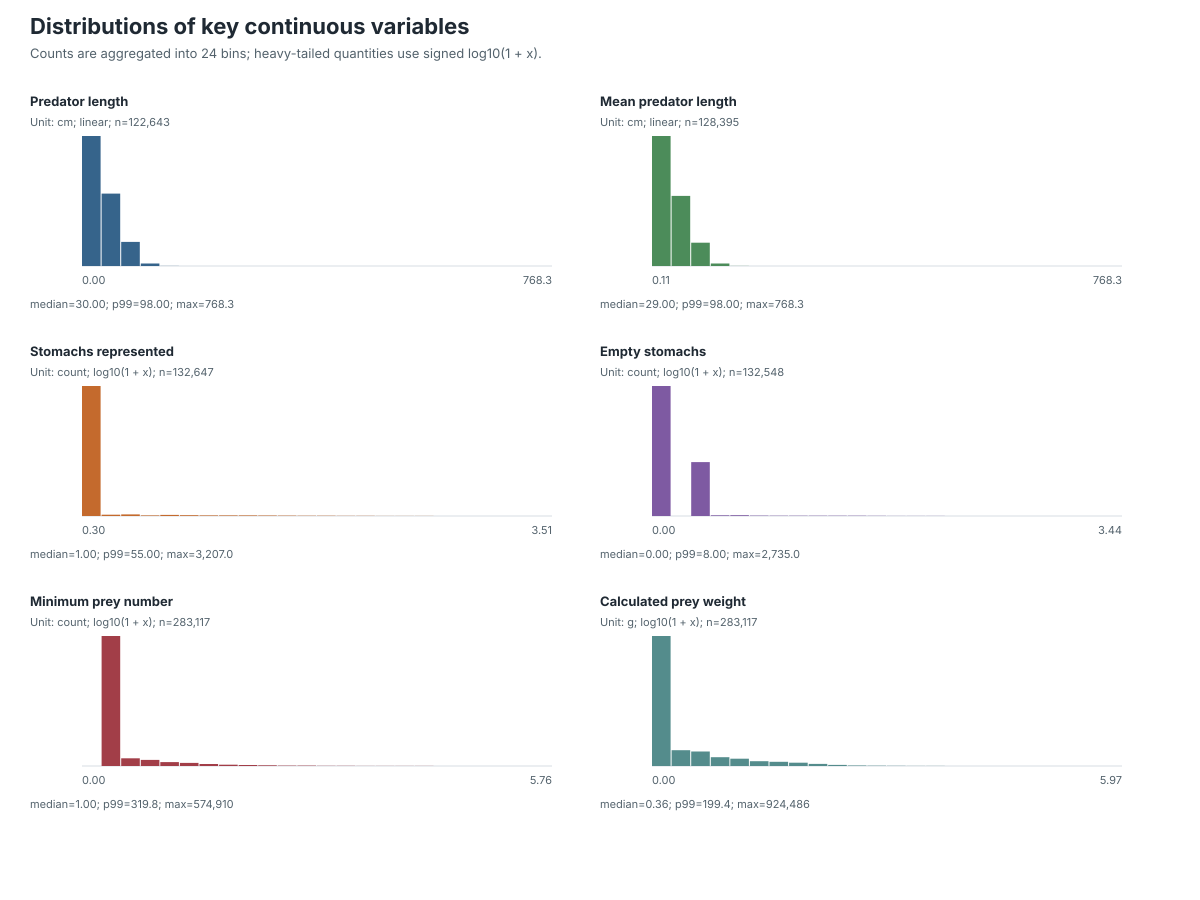

In [9]:
FIGURE_NAME = "numeric_variable_distributions.svg"

viz.numeric_distribution_grid(
    name=FIGURE_NAME,
    title="Distributions of key continuous variables",
    subtitle="Counts are aggregated into 24 bins; heavy-tailed quantities use signed log10(1 + x).",
    width=1200,
    height=900,
    panel_width=570,
    panel_height=250,
    palette=STYLE["palette"],
)
show_svg(FIGURE_NAME)


Extreme values are retained. Tukey-IQR flags in the main notebook are review prompts, not automatic deletions: pooled samples and rare dietary events can legitimately generate long tails.

## 7. Dominant Taxa

Source: `top_predators.csv`. Edit `LIMIT`, colour and label space.

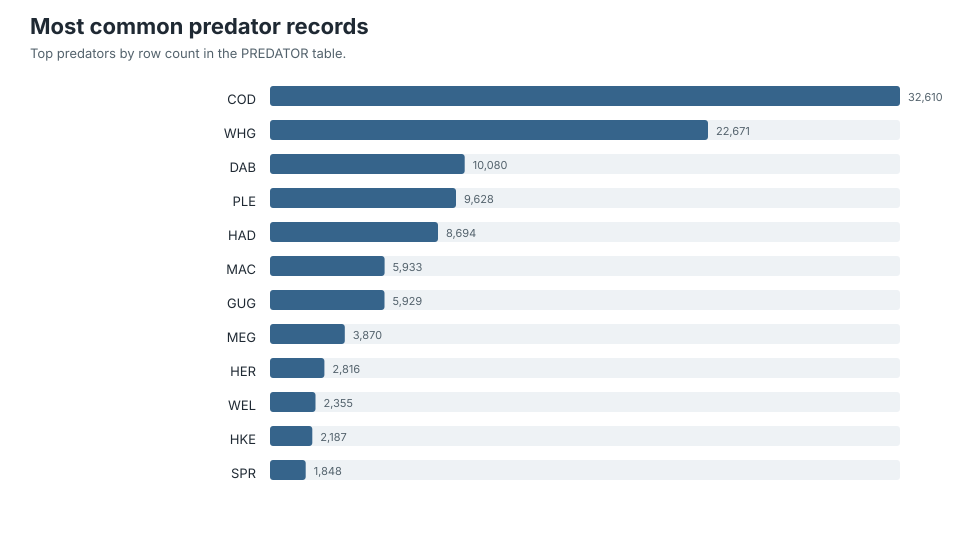

In [10]:
FIGURE_NAME = "top_predators.svg"
LIMIT = 12

rows = viz.read_rows("top_predators")
viz.horizontal_bar_chart(
    name=FIGURE_NAME,
    title="Most common predator records",
    subtitle="Top predators by row count in the PREDATOR table.",
    rows=rows,
    value_key="predator_rows",
    label_key="predator_name",
    limit=LIMIT,
    color=STYLE["predator"],
    width=980,
    row_height=34,
    left=270,
    right=80,
)
show_svg(FIGURE_NAME)


### Non-standard TSN categories

Source: `negative_tsn_prey_categories.csv`. This is a QC summary rather than a trophic network.

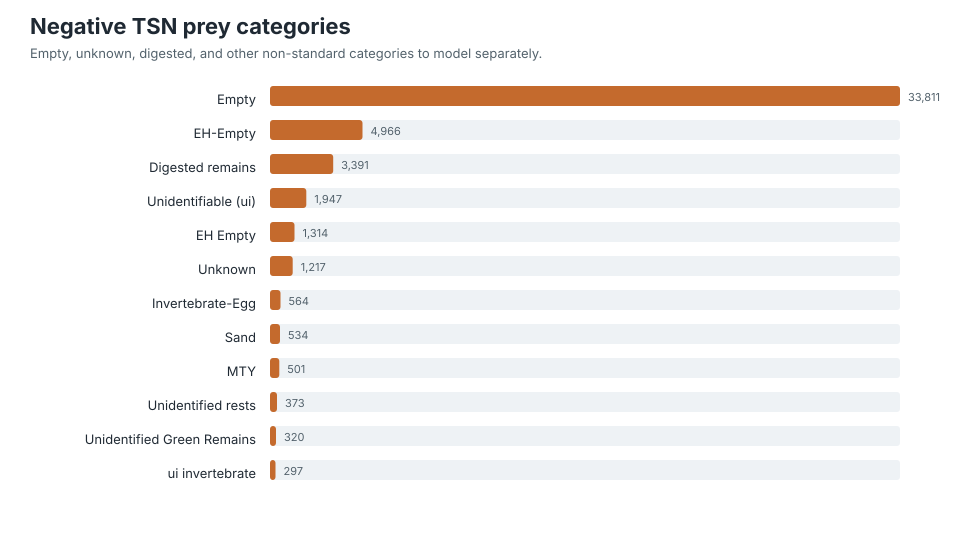

In [11]:
FIGURE_NAME = "negative_tsn_categories.svg"
LIMIT = 12

rows = viz.read_rows("negative_tsn_prey_categories")
viz.horizontal_bar_chart(
    name=FIGURE_NAME,
    title="Negative TSN prey categories",
    subtitle="Empty, unknown, digested, and other non-standard categories to model separately.",
    rows=rows,
    value_key="prey_rows",
    label_key="prey_name",
    limit=LIMIT,
    color=STYLE["non_trophic"],
    width=980,
    row_height=34,
    left=270,
    right=80,
)
show_svg(FIGURE_NAME)


The resolved-taxon primary graph requires `prey_tsn > 0`. Empty and non-trophic codes remain useful sampling/QC information; unresolved trophic codes (-99913 to -99915) belong in a sensitivity analysis.

## Derive complete sea × decade networks

This reconstructs unified TSN edges, complete-network metrics and the deterministic representative selection from derived CSV tables. It does not query or change the Access database.

In [12]:
networks, network_metrics, representatives = derive()
{
    "networks": len(networks),
    "metric_rows": len(network_metrics),
    "representatives": [
        (row["complexity_tier"], row["sea"], row["decade"])
        for row in representatives
    ],
}


{'networks': 135,
 'metric_rows': 135,
 'representatives': [('high', 'North Sea', 1900),
  ('median', 'Channel', 1930),
  ('low', 'Irish Sea', 1900)]}

## 8. Network-property Distributions

Change `BINS` or `METRICS` to adjust the number and definition of panels.

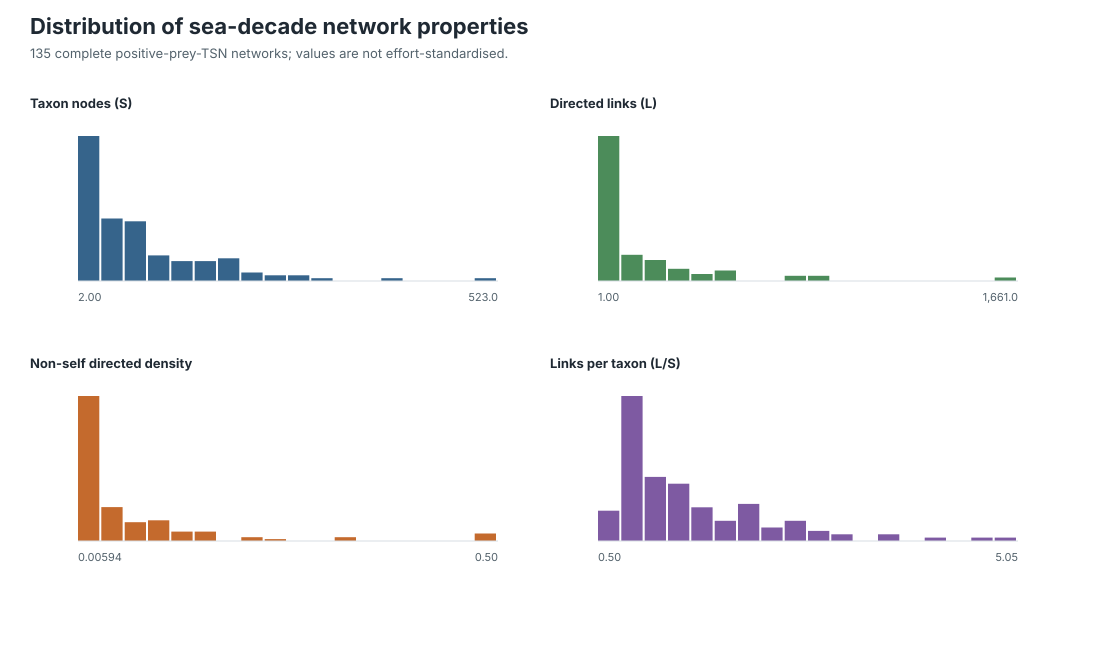

In [13]:
FIGURE_NAME = "network_metric_distributions.svg"
BINS = 18
METRICS = [
    ("taxon_nodes", "Taxon nodes (S)", STYLE["predator"]),
    ("directed_edges", "Directed links (L)", STYLE["prey"]),
    ("nonself_directed_density", "Non-self directed density", STYLE["non_trophic"]),
    ("links_per_taxon", "Links per taxon (L/S)", STYLE["both_roles"]),
]

viz.network_metric_distribution_grid(
    network_metrics,
    name=FIGURE_NAME,
    title="Distribution of sea-decade network properties",
    subtitle=f"{len(network_metrics)} complete positive-prey-TSN networks; values are not effort-standardised.",
    definitions=METRICS,
    width=1100,
    height=650,
    panel_width=520,
    panel_height=260,
    bins=BINS,
)
show_svg(FIGURE_NAME)


## 9. Spatial and Temporal Network Coverage

Source: `edge_pairs_by_sea_decade_positive_prey_tsn.csv`. Edit sea count, cell geometry, colour scale and label threshold.

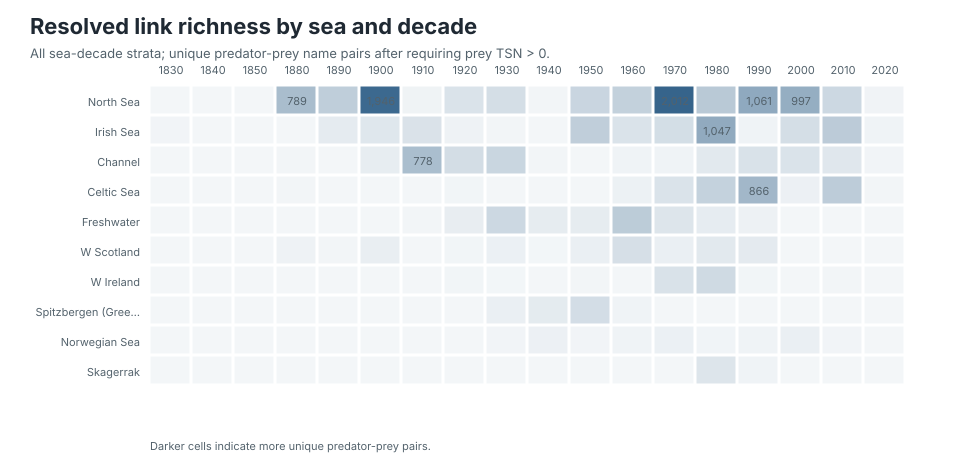

In [14]:
FIGURE_NAME = "sea_decade_edge_heatmap.svg"
SEA_LIMIT = 10

viz.heatmap_sea_decade(
    name=FIGURE_NAME,
    title="Resolved link richness by sea and decade",
    subtitle="All sea-decade strata; unique predator-prey name pairs after requiring prey TSN > 0.",
    sea_limit=SEA_LIMIT,
    cell_width=42,
    cell_height=30,
    low_color="#F3F6F8",
    high_color=STYLE["predator"],
    label_threshold=0.38,
)
show_svg(FIGURE_NAME)


This heatmap reports **link richness**, not density. All positive-prey-TSN strata are included.

### Sampling effort versus link richness

Point sizes, opacity, canvas dimensions and colours are editable.

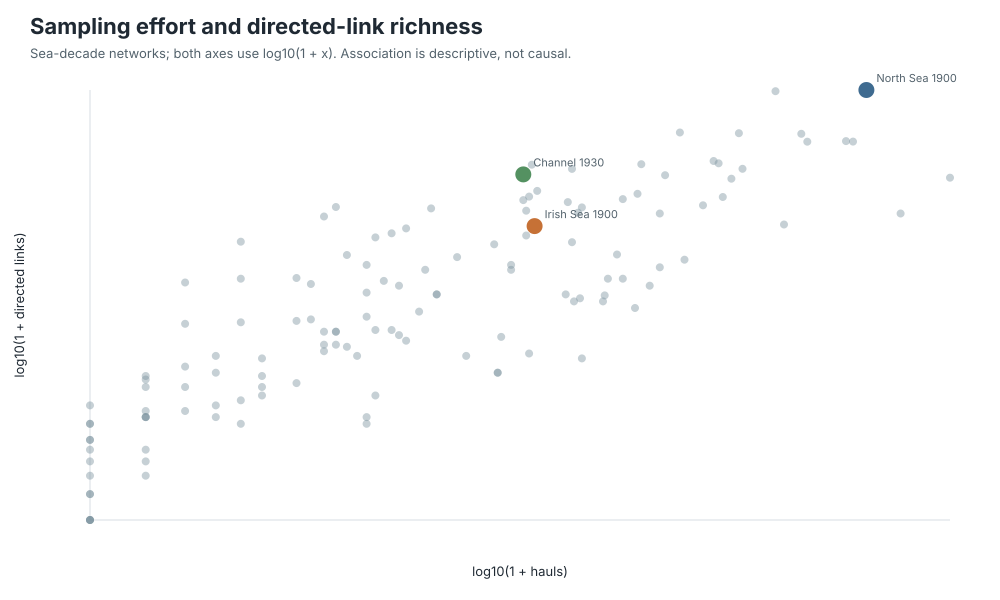

In [15]:
FIGURE_NAME = "effort_vs_directed_edges.svg"

viz.effort_vs_edges_chart(
    network_metrics,
    representatives,
    name=FIGURE_NAME,
    title="Sampling effort and directed-link richness",
    subtitle="Sea-decade networks; both axes use log10(1 + x). Association is descriptive, not causal.",
    width=1000,
    height=600,
    background_point_color="#78909C",
    background_point_opacity=0.42,
    background_point_radius=4,
    representative_point_radius=8,
)
show_svg(FIGURE_NAME)


The effort-link association is descriptive. Comparisons require effort adjustment and sensitivity analyses.

## 10. Global Filter Diagnostic — raw categories

This QC flow includes non-positive categories. `LIMIT` controls the displayed edge backbone.

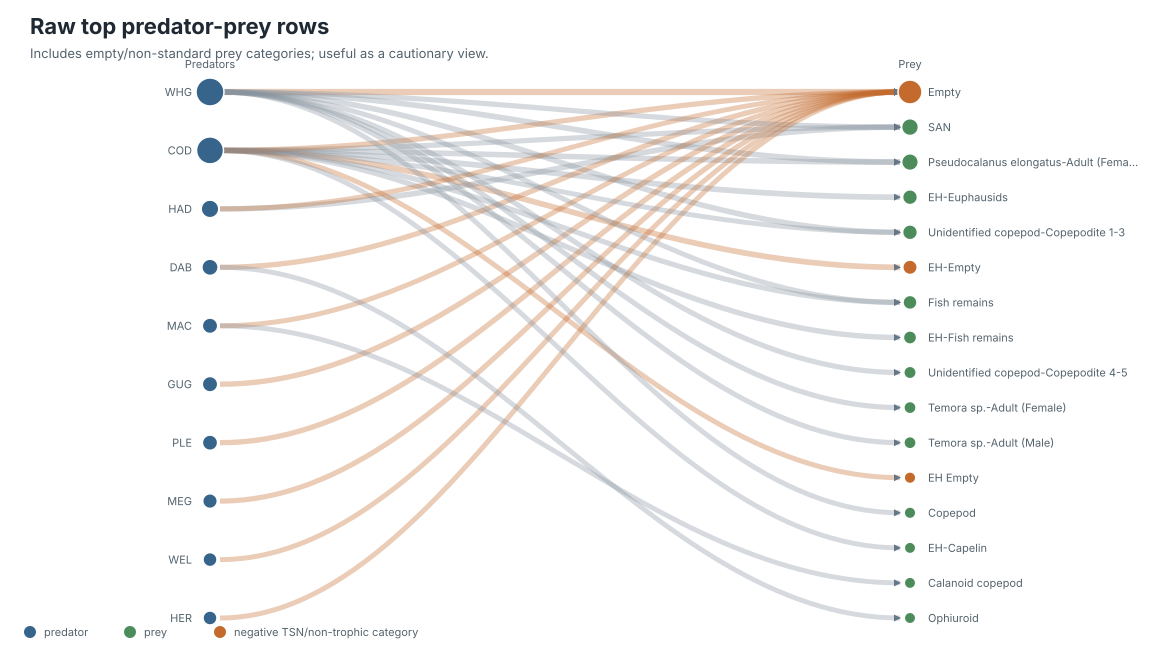

In [16]:
FIGURE_NAME = "network_top_raw_edges.svg"
LIMIT = 30

rows = viz.read_rows("top_predator_prey_edges")
viz.edge_network(
    name=FIGURE_NAME,
    title="Raw top predator-prey rows",
    subtitle="Includes empty/non-standard prey categories; useful as a cautionary view.",
    rows=rows,
    limit=LIMIT,
    include_negative=True,
    width=1160,
    minimum_height=660,
    row_spacing=25,
    edge_opacity=0.34,
    negative_color=STYLE["non_trophic"],
)
show_svg(FIGURE_NAME)


### Global positive-TSN diagnostic

This uses the positive-prey-TSN top-edge table. Modify `LIMIT`, spacing or edge opacity.

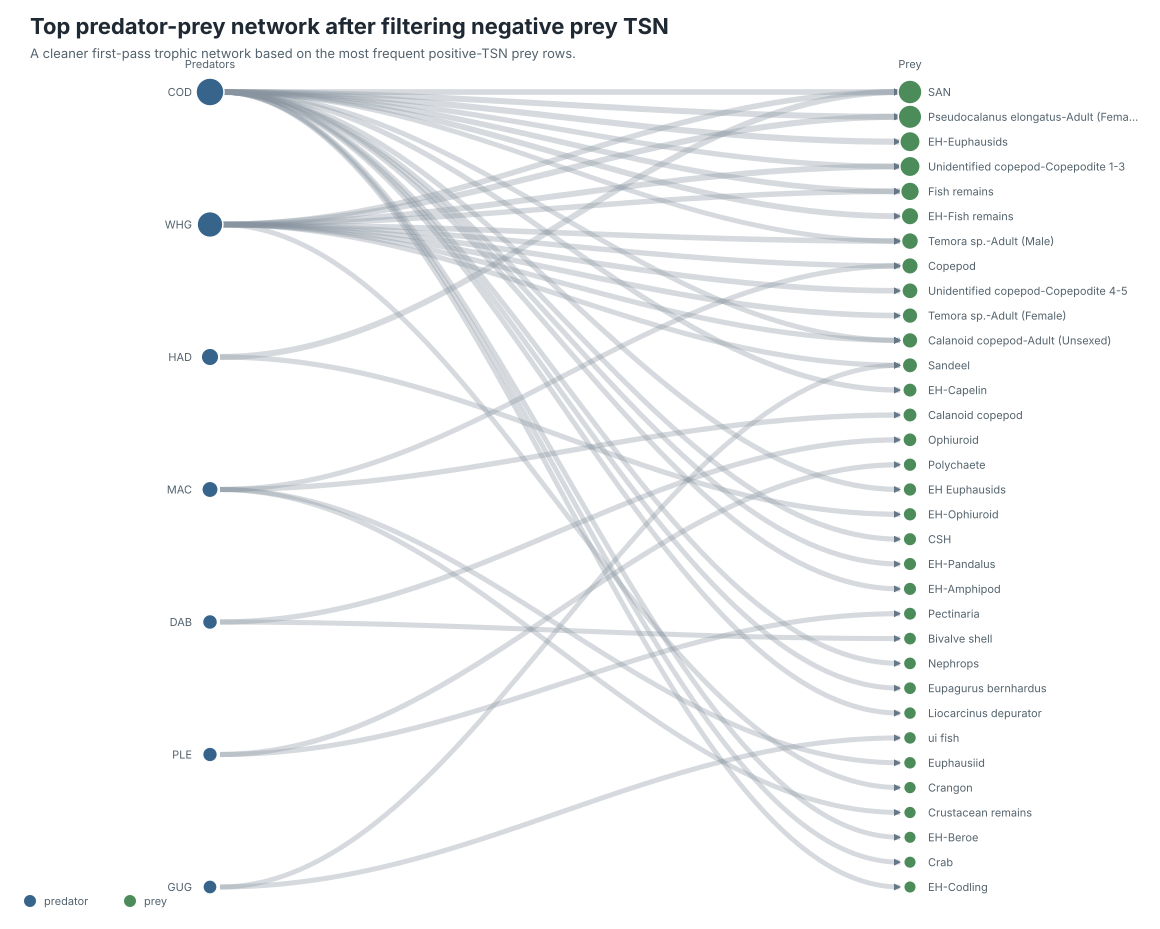

In [17]:
FIGURE_NAME = "network_positive_prey_tsn_edges.svg"
LIMIT = 42

rows = viz.read_rows("top_predator_prey_edges_positive_prey_tsn")
viz.edge_network(
    name=FIGURE_NAME,
    title="Top predator-prey network after filtering negative prey TSN",
    subtitle="A cleaner first-pass trophic network based on the most frequent positive-TSN prey rows.",
    rows=rows,
    limit=LIMIT,
    include_negative=False,
    width=1160,
    minimum_height=660,
    row_spacing=25,
    edge_opacity=0.34,
)
show_svg(FIGURE_NAME)


## 11. Representative Individual Networks

Selection rule: among strata with at least **30 hauls**, **10 predator taxa** and **100 prey taxa**, select high, median and low directed-link complexity while preferring different seas.

| Tier | Sea | Decade | Hauls | S | L | Non-self density | L/S | Largest component |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| High | North Sea | 1900 | 571 | 523 | 1,661 | 0.0061 | 3.18 | 99.6% |
| Median | Channel | 1930 | 46 | 151 | 443 | 0.0196 | 2.93 | 100.0% |
| Low | Irish Sea | 1900 | 50 | 134 | 197 | 0.0111 | 1.47 | 100.0% |

### How to read and customise the network figures

- **Node:** one unified positive TSN; a taxon appearing in both roles is drawn once.
- **Colour:** blue = predator-only, green = prey-only, purple = both roles.
- **Arrow:** `predator → consumed prey`; ecological energy flow is the reverse.
- **Displayed structure:** the most supported links, controlled by `LIMIT`.
- **Editable parameters:** role colours, column positions, node-radius range, edge-width range, edge opacity, row spacing and canvas dimensions.

### High complexity — North Sea 1900

Complete graph: S=523, L=1661, non-self density=0.0061.

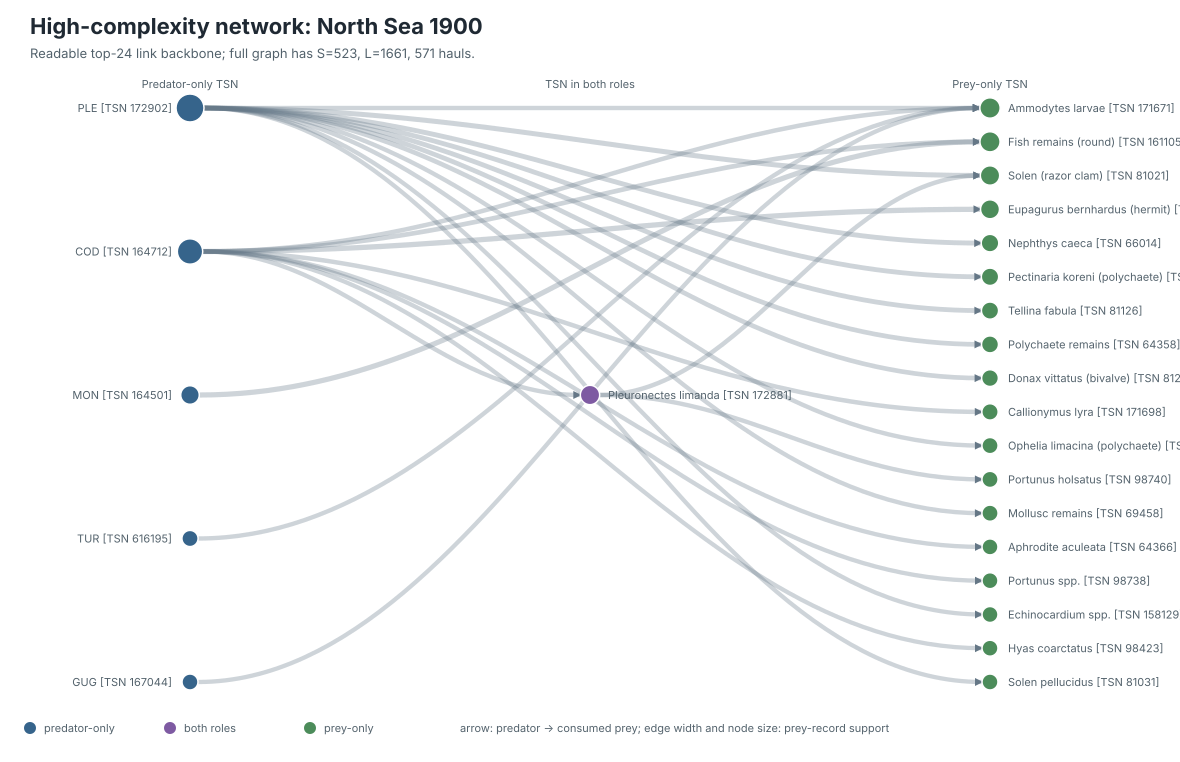

In [18]:
FIGURE_NAME = 'network_representative_1_north_sea_1900.svg'
REPRESENTATIVE_KEY = ('North Sea', 1900)
LIMIT = 24

representative_row = next(
    row
    for row in representatives
    if (row["sea"], viz.as_int(row["decade"])) == REPRESENTATIVE_KEY
)
viz.unified_network_backbone(
    name=FIGURE_NAME,
    title=(
        representative_row["complexity_tier"].capitalize()
        + "-complexity network: "
        + representative_row["sea"]
        + " "
        + str(viz.as_int(representative_row["decade"]))
    ),
    subtitle=(
        "Readable top-{} link backbone; full graph has S={}, L={}, {} hauls."
        .format(
            LIMIT,
            viz.as_int(representative_row["taxon_nodes"]),
            viz.as_int(representative_row["directed_edges"]),
            viz.as_int(representative_row["hauls"]),
        )
    ),
    full_edges=networks[REPRESENTATIVE_KEY],
    limit=LIMIT,
    width=1180,
    minimum_height=720,
    row_spacing=34,
    role_x_positions={"predator": 190, "both": 590, "prey": 990},
    role_colors={
        "predator": STYLE["predator"],
        "both": STYLE["both_roles"],
        "prey": STYLE["prey"],
    },
    edge_color="#657786",
    edge_opacity=0.32,
    minimum_node_radius=6,
    node_radius_range=8,
    minimum_edge_width=0.8,
    edge_width_range=4.5,
)
show_svg(FIGURE_NAME)


### Median complexity — Channel 1930

Complete graph: S=151, L=443, non-self density=0.0196.

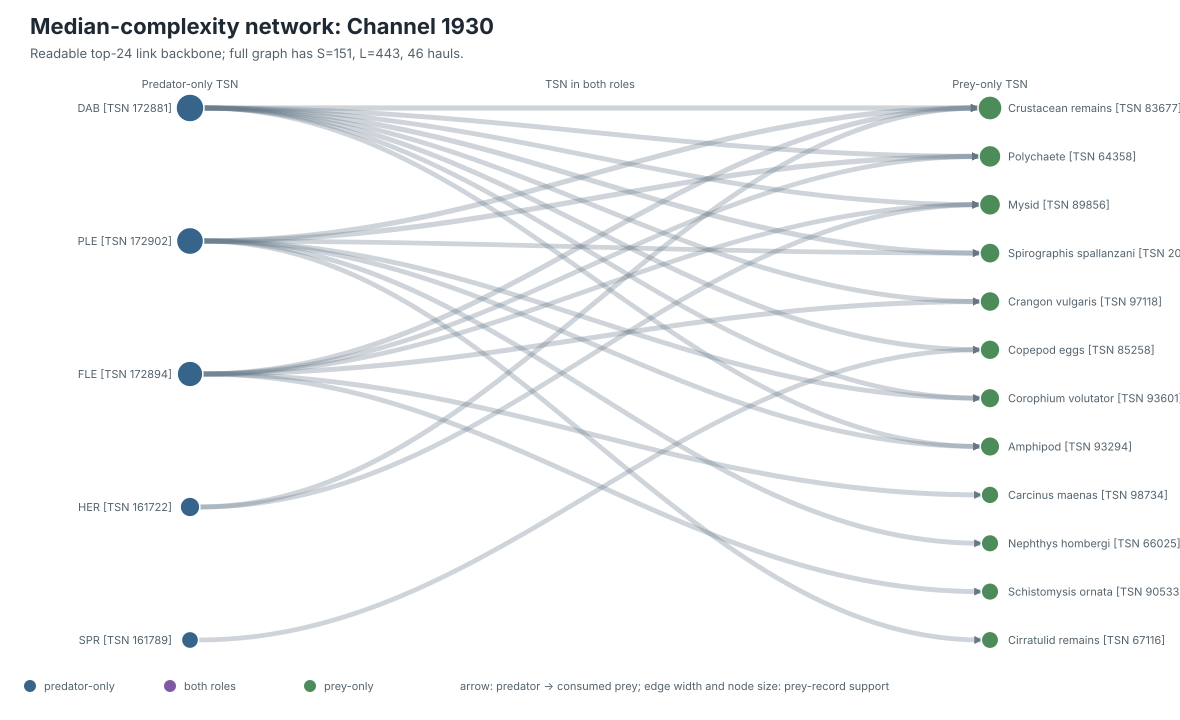

In [19]:
FIGURE_NAME = 'network_representative_2_channel_1930.svg'
REPRESENTATIVE_KEY = ('Channel', 1930)
LIMIT = 24

representative_row = next(
    row
    for row in representatives
    if (row["sea"], viz.as_int(row["decade"])) == REPRESENTATIVE_KEY
)
viz.unified_network_backbone(
    name=FIGURE_NAME,
    title=(
        representative_row["complexity_tier"].capitalize()
        + "-complexity network: "
        + representative_row["sea"]
        + " "
        + str(viz.as_int(representative_row["decade"]))
    ),
    subtitle=(
        "Readable top-{} link backbone; full graph has S={}, L={}, {} hauls."
        .format(
            LIMIT,
            viz.as_int(representative_row["taxon_nodes"]),
            viz.as_int(representative_row["directed_edges"]),
            viz.as_int(representative_row["hauls"]),
        )
    ),
    full_edges=networks[REPRESENTATIVE_KEY],
    limit=LIMIT,
    width=1180,
    minimum_height=720,
    row_spacing=34,
    role_x_positions={"predator": 190, "both": 590, "prey": 990},
    role_colors={
        "predator": STYLE["predator"],
        "both": STYLE["both_roles"],
        "prey": STYLE["prey"],
    },
    edge_color="#657786",
    edge_opacity=0.32,
    minimum_node_radius=6,
    node_radius_range=8,
    minimum_edge_width=0.8,
    edge_width_range=4.5,
)
show_svg(FIGURE_NAME)


### Low complexity — Irish Sea 1900

Complete graph: S=134, L=197, non-self density=0.0111.

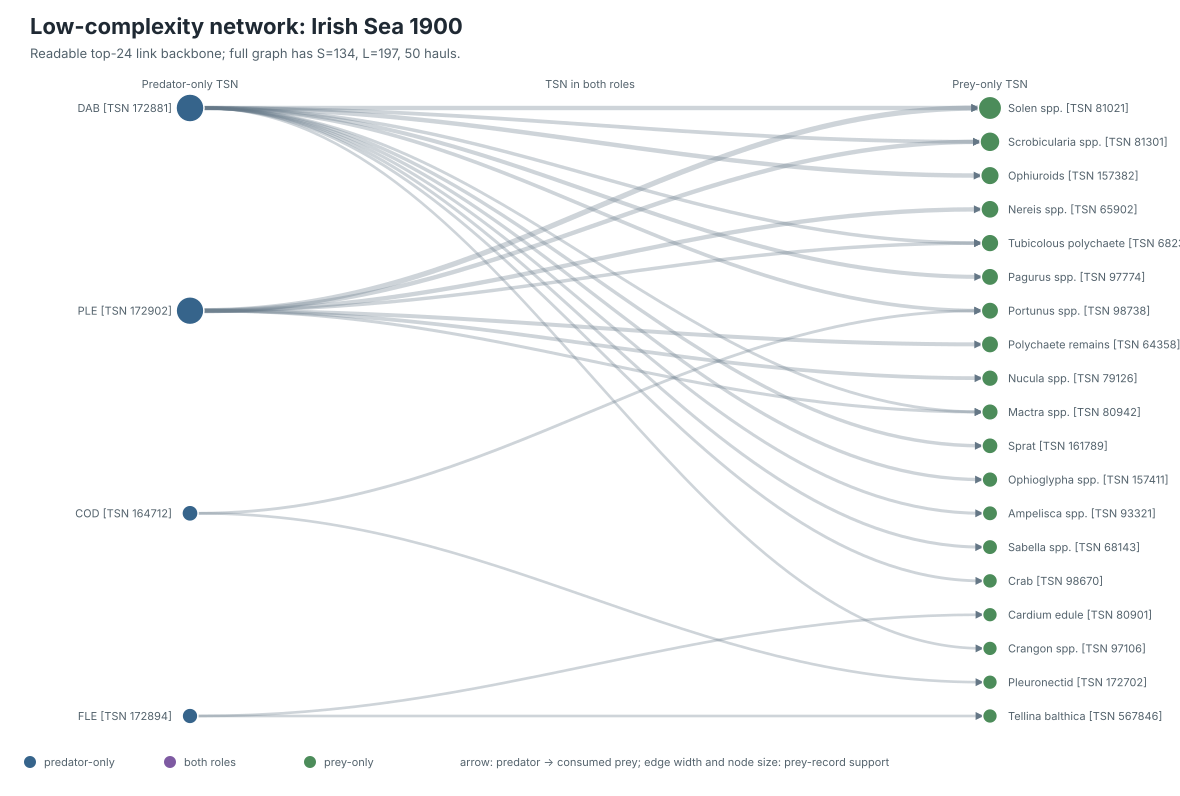

In [20]:
FIGURE_NAME = 'network_representative_3_irish_sea_1900.svg'
REPRESENTATIVE_KEY = ('Irish Sea', 1900)
LIMIT = 24

representative_row = next(
    row
    for row in representatives
    if (row["sea"], viz.as_int(row["decade"])) == REPRESENTATIVE_KEY
)
viz.unified_network_backbone(
    name=FIGURE_NAME,
    title=(
        representative_row["complexity_tier"].capitalize()
        + "-complexity network: "
        + representative_row["sea"]
        + " "
        + str(viz.as_int(representative_row["decade"]))
    ),
    subtitle=(
        "Readable top-{} link backbone; full graph has S={}, L={}, {} hauls."
        .format(
            LIMIT,
            viz.as_int(representative_row["taxon_nodes"]),
            viz.as_int(representative_row["directed_edges"]),
            viz.as_int(representative_row["hauls"]),
        )
    ),
    full_edges=networks[REPRESENTATIVE_KEY],
    limit=LIMIT,
    width=1180,
    minimum_height=720,
    row_spacing=34,
    role_x_positions={"predator": 190, "both": 590, "prey": 990},
    role_colors={
        "predator": STYLE["predator"],
        "both": STYLE["both_roles"],
        "prey": STYLE["prey"],
    },
    edge_color="#657786",
    edge_opacity=0.32,
    minimum_node_radius=6,
    node_radius_range=8,
    minimum_edge_width=0.8,
    edge_width_range=4.5,
)
show_svg(FIGURE_NAME)


## 12. Structural Comparison

Complete-graph comparison. Edit `COMPARISON_METRICS` to add, remove or rename rows.

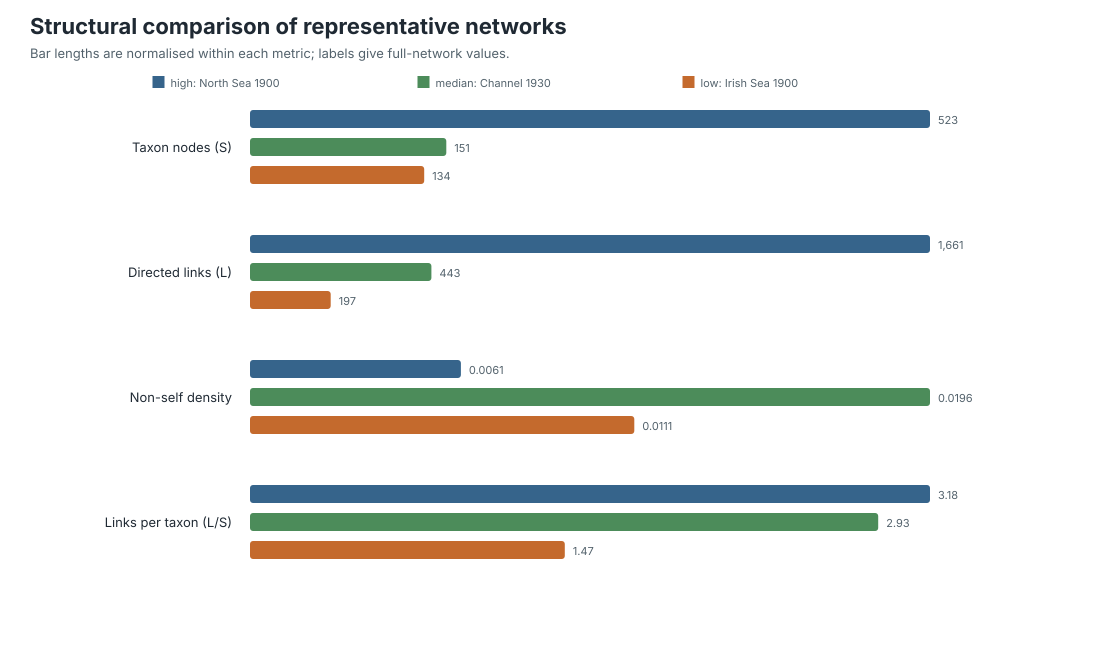

In [21]:
FIGURE_NAME = "representative_network_metric_comparison.svg"
COMPARISON_METRICS = [
    ("taxon_nodes", "Taxon nodes (S)", lambda value: viz.fmt_int(value)),
    ("directed_edges", "Directed links (L)", lambda value: viz.fmt_int(value)),
    (
        "nonself_directed_density",
        "Non-self density",
        lambda value: f"{viz.as_float(value):.4f}",
    ),
    ("links_per_taxon", "Links per taxon (L/S)", lambda value: viz.fmt_num(value)),
]

viz.representative_metric_comparison(
    representatives,
    name=FIGURE_NAME,
    title="Structural comparison of representative networks",
    subtitle="Bar lengths are normalised within each metric; labels give full-network values.",
    definitions=COMPARISON_METRICS,
    width=1100,
    height=660,
    colors=STYLE["palette"][: len(representatives)],
    legend_start_x=None,  # None centres the complete legend group
    legend_item_width=265,
)
show_svg(FIGURE_NAME)


**Channel 1930** is densest among the selected examples (0.0196); **Irish Sea 1900** has the largest top-10 link record share (40.0%). Differences in S, L, density, L/S and concentration remain hypotheses for effort- and provenance-aware analysis.

## Interpretation Boundary

Formal ecological comparisons must follow the preprocessing, grouped statistical analyses and validation sequence in `DAPSTOM_EDA.ipynb`. Stable SVG filenames are preserved so presentation assets continue to work after visual customisation.